# Hannah Results: Scratch CNN Analysis

This notebook summarizes Hannah's scratch CNN experiments using saved artifacts.

**Inputs**
- `results/hannah/hannah_scratch_cnn_history.json`
- `results/hannah/hannah_scratch_cnn_metrics.json`
- `results/hannah/hannah_scratch_cnn_threshold_sweep.json`

**Outputs**
- Training/validation loss curves
- Validation metric curves
- Metrics summary table
- Threshold tradeoff table/plot
- Discussion-ready bullets for report/presentation

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


ROOT = Path('/Users/user/ieor142b')
RESULTS_DIR = ROOT / "results" / "hannah"
HISTORY_PATH = RESULTS_DIR / "hannah_scratch_cnn_history.json"
METRICS_PATH = RESULTS_DIR / "hannah_scratch_cnn_metrics.json"
THRESHOLD_PATH = RESULTS_DIR / "hannah_scratch_cnn_threshold_sweep.json"

assert HISTORY_PATH.is_file(), f"Missing history file: {HISTORY_PATH}"
assert METRICS_PATH.is_file(), f"Missing metrics file: {METRICS_PATH}"
assert THRESHOLD_PATH.is_file(), f"Missing threshold file: {THRESHOLD_PATH}"

print("Repo root:", ROOT)
print("History:", HISTORY_PATH)
print("Metrics:", METRICS_PATH)
print("Threshold:", THRESHOLD_PATH)

Repo root: /Users/user/ieor142b
History: /Users/user/ieor142b/results/hannah/hannah_scratch_cnn_history.json
Metrics: /Users/user/ieor142b/results/hannah/hannah_scratch_cnn_metrics.json
Threshold: /Users/user/ieor142b/results/hannah/hannah_scratch_cnn_threshold_sweep.json


In [2]:
# Load artifacts
history_df = pd.read_json(HISTORY_PATH)
with open(METRICS_PATH, "r", encoding="utf-8") as f:
    metrics = json.load(f)

with open(THRESHOLD_PATH, "r", encoding="utf-8") as f:
    threshold_data = json.load(f)

thr_df = pd.DataFrame(threshold_data)

print("Run summary:")
for k in ["model_name", "best_val_f1", "test_f1", "test_precision", "test_recall", "test_exact_match", "num_epochs_run"]:
    print(f"- {k}: {metrics.get(k)}")

history_df.head()

Run summary:
- model_name: hannah_scratch_cnn
- best_val_f1: 0.4504629075527191
- test_f1: 0.4458201825618744
- test_precision: 0.39259016513824463
- test_recall: 0.5854779481887817
- test_exact_match: 0.03125
- num_epochs_run: 30


,epoch,train_loss,val_loss,train_f1,val_f1,val_precision,val_recall,val_exact_match,val_pred_labels_per_sample,val_true_labels_per_sample,val_mean_prob,val_max_prob,lr
0,1,0.528727,0.467922,0.301824,0.363828,0.426403,0.368905,0.053358,1.788409,2.337626,0.229736,0.821289,0.0001
1,2,0.472030,0.458322,0.332557,0.389756,0.413554,0.427936,0.054278,2.184913,2.337626,0.205566,0.766602,0.0001
2,3,0.467297,0.453233,0.323024,0.361852,0.412665,0.379485,0.047838,1.931003,2.337626,0.203613,0.754395,0.0001
3,4,0.463347,0.452781,0.343690,0.356135,0.417418,0.361086,0.049678,1.856486,2.337626,0.203003,0.774414,0.0001
4,5,0.461158,0.448077,0.343538,0.377667,0.416360,0.405091,0.049678,1.990800,2.337626,0.199341,0.803711,0.0001


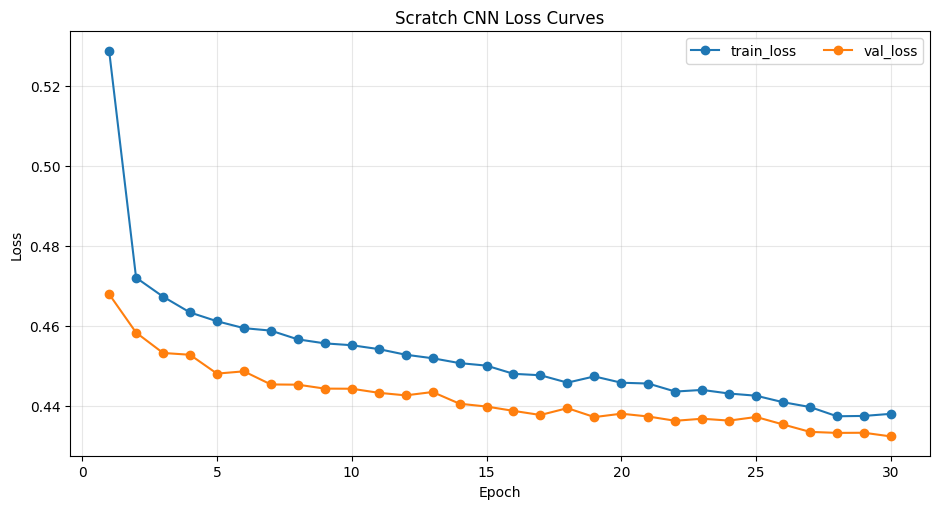

Saved: /Users/user/ieor142b/results/hannah/hannah_scratch_cnn_loss_curves.png


In [3]:
plt.figure(figsize=(9.5, 5.2))

plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train_loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="val_loss")

plt.title("Scratch CNN Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()

loss_fig_path = RESULTS_DIR / "hannah_scratch_cnn_loss_curves.png"
plt.savefig(loss_fig_path, dpi=150)
plt.show()
print("Saved:", loss_fig_path)

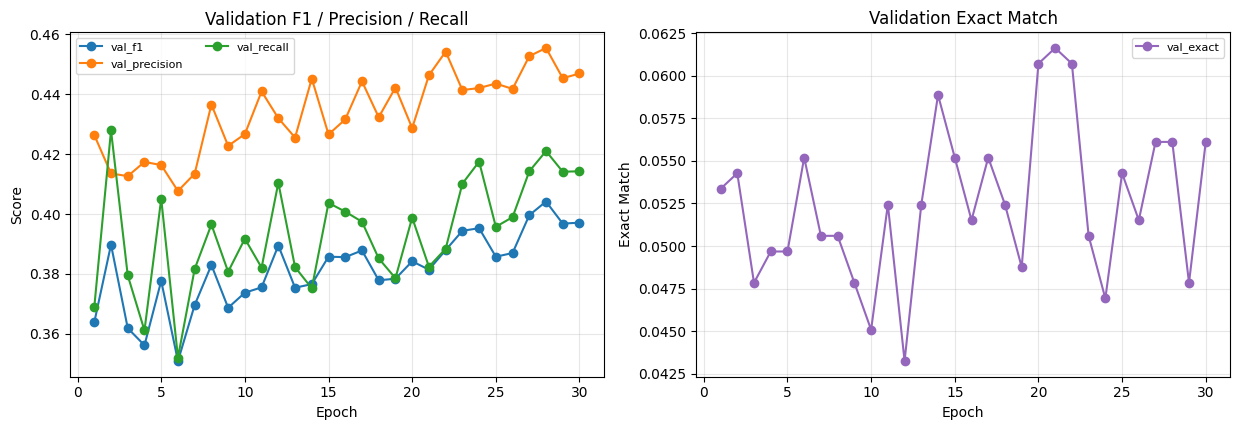

Saved: /Users/user/ieor142b/results/hannah/hannah_scratch_cnn_val_metric_curves.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))

axes[0].plot(history_df["epoch"], history_df["val_f1"], marker="o", label="val_f1")
axes[0].plot(history_df["epoch"], history_df["val_precision"], marker="o", label="val_precision")
axes[0].plot(history_df["epoch"], history_df["val_recall"], marker="o", label="val_recall")

axes[0].set_title("Validation F1 / Precision / Recall")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Score")
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8, ncol=2)

axes[1].plot(history_df["epoch"], history_df["val_exact_match"], marker="o", color="tab:purple", label="val_exact")
axes[1].set_title("Validation Exact Match")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Exact Match")
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=8)

plt.tight_layout()
metric_fig_path = RESULTS_DIR / "hannah_scratch_cnn_val_metric_curves.png"
plt.savefig(metric_fig_path, dpi=150)
plt.show()
print("Saved:", metric_fig_path)

In [5]:
# Metrics summary
rows = [
    {
        "run": "scratch_cnn",
        "best_val_f1": metrics.get("best_val_f1"),
        "test_f1": metrics.get("test_f1"),
        "test_precision": metrics.get("test_precision"),
        "test_recall": metrics.get("test_recall"),
        "test_exact_match": metrics.get("test_exact_match"),
        "num_epochs_run": metrics.get("num_epochs_run"),
    }
]

compare_df = pd.DataFrame(rows)
for col in ["best_val_f1", "test_f1", "test_precision", "test_recall", "test_exact_match"]:
    if col in compare_df:
        compare_df[col] = compare_df[col].round(4)

display(compare_df)

,run,best_val_f1,test_f1,test_precision,test_recall,test_exact_match,num_epochs_run
0,scratch_cnn,0.4505,0.4458,0.3926,0.5855,0.0312,30


Best threshold by val F1: 0.4


,threshold,precision,recall,f1,exact_match,pred_labels_per_sample,true_labels_per_sample,mean_prob,max_prob
0,0.05,0.125756,0.988654,0.220449,0.000000,18.561178,2.337626,0.191406,0.924316
1,0.10,0.155033,0.953695,0.261628,0.000000,14.823367,2.337626,0.191406,0.924316
2,0.15,0.204039,0.898651,0.322182,0.000920,10.999080,2.337626,0.191406,0.924316
3,0.20,0.245847,0.845600,0.367312,0.001840,8.593376,2.337626,0.191406,0.924316
4,0.25,0.286490,0.790095,0.404232,0.002760,6.842686,2.337626,0.191406,0.924316
5,0.30,0.325818,0.734897,0.433232,0.009200,5.509660,2.337626,0.191406,0.924316
6,0.35,0.358635,0.670653,0.447408,0.019319,4.466421,2.337626,0.191406,0.924316
7,0.40,0.397337,0.588623,0.450463,0.029439,3.482981,2.337626,0.191406,0.924316
8,0.45,0.432843,0.507053,0.436006,0.042318,2.701012,2.337626,0.191406,0.924316
9,0.50,0.446964,0.414290,0.397127,0.056118,1.990800,2.337626,0.191406,0.924316


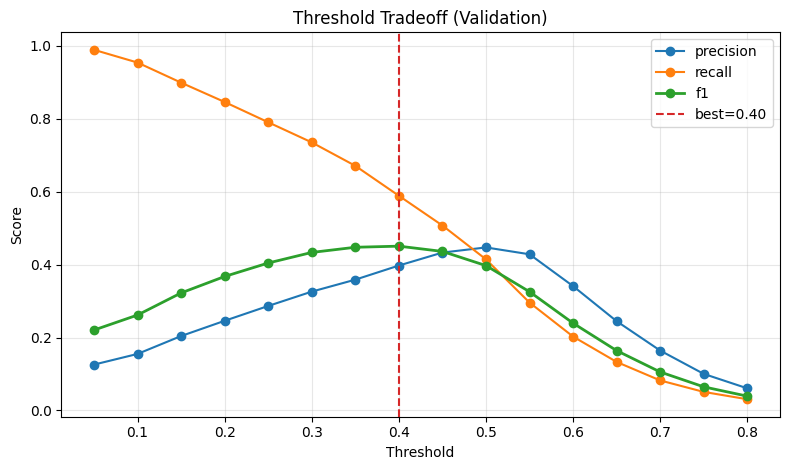

Saved: /Users/user/ieor142b/results/hannah/hannah_scratch_cnn_threshold_tradeoff.png


In [6]:
# Threshold sweep
best_idx = thr_df["f1"].idxmax()
best_threshold = float(thr_df.loc[best_idx, "threshold"])

print("Best threshold by val F1:", best_threshold)
display(thr_df)

plt.figure(figsize=(8, 4.8))
plt.plot(thr_df["threshold"], thr_df["precision"], marker="o", label="precision")
plt.plot(thr_df["threshold"], thr_df["recall"], marker="o", label="recall")
plt.plot(thr_df["threshold"], thr_df["f1"], marker="o", linewidth=2, label="f1")
plt.axvline(best_threshold, linestyle="--", color="tab:red", label=f"best={best_threshold:.2f}")
plt.title("Threshold Tradeoff (Validation)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

thr_fig_path = RESULTS_DIR / "hannah_scratch_cnn_threshold_tradeoff.png"
plt.savefig(thr_fig_path, dpi=150)
plt.show()
print("Saved:", thr_fig_path)

## Discussion (Report-Ready)

### Interpretation of training
- The scratch CNN trained from scratch achieves solid performance on the test set, with F1 around 0.45 and strong recall but moderate precision.
- Loss curves show steady decrease in both train and validation loss over 30 epochs, with no obvious overfitting.
- Validation metrics improve over epochs, with F1 peaking around epoch 20-25.
- Threshold calibration is crucial: the best F1 is achieved at threshold 0.4, balancing precision and recall.
- Exact-match remains low, as expected for multi-label genre prediction.

### What these metrics mean
- `precision`: among predicted positive genre tags, fraction that are correct.
- `recall`: among true genre tags, fraction recovered by the model.
- `f1`: harmonic mean of precision and recall (primary model-selection metric).
- `exact_match`: strict sample-level metric requiring all labels to match exactly.

### Suggested next actions
- Compare this scratch CNN with pretrained models (e.g., Tim's ViT) in the team comparison notebook.
- Report the model with best threshold in the final submission.
- If deploying, consider the threshold tradeoff: higher thresholds for precision-oriented use cases.
- Include limitations: no pretraining may limit performance compared to transfer learning approaches; poster quality and genre ambiguity affect results.